In [232]:
!pip -q install chess ipywidgets

In [233]:
!pip install kagglehub

## Imports and setup

In [235]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, LeakyReLU,
    MaxPooling2D, Dropout, Flatten, Dense
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from functools import lru_cache

import math
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict

import chess
import ipywidgets as W
from IPython.display import display, HTML

## FEN to array conversion

In [237]:
# Convert FEN positions to numerical feature representations
piece_to_index = {
    'p':0, 'n':1, 'b':2, 'r':3, 'q':4, 'k':5,
    'P':6, 'N':7, 'B':8, 'R':9, 'Q':10, 'K':11
}

piece_value = {1: 1, 2: 3, 3: 3, 4: 5, 5: 9, 6: 0}  # basic material weights

def fen_to_array(fen: str) -> np.ndarray:
    board = chess.Board(fen)
    
    # --- Base piece representation (8x8x12) ---
    arr = np.zeros((8, 8, 14), dtype=np.float32)  # 12 pieces + 2 extra channels

    # Fill piece planes
    for sq, pc in board.piece_map().items():
        r = 7 - chess.square_rank(sq)
        c = chess.square_file(sq)
        arr[r, c, piece_to_index[pc.symbol()]] = 1.0

    # --- Extra channel 1: side to move ---
    side_channel = 12
    if board.turn == chess.WHITE:
        arr[:, :, side_channel] = 1.0  # entire plane = 1 if white to move

    # --- Extra channel 2: material balance ---
    material_balance = sum(
        piece_value[p.piece_type] * (1 if p.color == chess.WHITE else -1)
        for p in board.piece_map().values()
    ) / 39.0  # normalize to [-1,1]
    arr[:, :, 13] = material_balance  # fill plane with same value

    return arr  # shape: (8, 8, 14)

# Scores can have outliers. Clip to keep training stable, then normalize to [-1, 1]
CP_CLIP = 3000.0

def cp_to_target(cp: float) -> float:
    return float(np.clip(cp, -CP_CLIP, CP_CLIP) / CP_CLIP)

def target_to_cp(t: float) -> float:
    return float(t) * CP_CLIP

In [238]:
# Download and load Kaggle dataset
path = kagglehub.dataset_download("ronakbadhe/chess-evaluations")

print("Path to dataset files:", path)

data_path = os.path.join(path, "chessData.csv")  
df = pd.read_csv(data_path)
df.head()

Path to dataset files: /Users/tamtran/.cache/kagglehub/datasets/ronakbadhe/chess-evaluations/versions/5


,FEN,Evaluation
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,+56
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,+52
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26


## Data Preprocessing

In [240]:
# Detect column names
fen_col = next(c for c in df.columns if 'fen' in c.lower())
eval_col = next(c for c in df.columns if 'eval' in c.lower() or 'score' in c.lower())

# Filter out non-numeric or special evaluations
def parse_eval(v):
    s = str(v).strip()
    if s.startswith('M') or s.startswith('#'):
        return np.sign(float(s.replace('M', '').replace('#', '') or 1)) * 100000.0
    try:
        return float(s)
    except ValueError:
        return np.nan

# Drop invalid rows
df = df.dropna(subset=[fen_col, eval_col]).copy()

# Convert to centipawns
df['cp'] = df[eval_col].apply(parse_eval)
df = df.dropna(subset=['cp']).reset_index(drop=True)

# Clip extreme outliers and normalize
CP_CLIP = 3000.0
df['cp'] = np.clip(df['cp'], -CP_CLIP, CP_CLIP)
df['target'] = df['cp'] / CP_CLIP

# Remove duplicates
df = df.drop_duplicates(subset=[fen_col])

# Limit to 1000k samples for faster training
df = df.sample(n=min(len(df), 1_000_000), random_state=42).reset_index(drop=True)

### Balancing the Dataset
To ensure the model learns evenly across all evaluation score ranges, inverse-frequency sample weights are computed based on target distribution bins. This approach prevents the model from being biased toward more common score ranges while keeping the dataset size fixed.

Raw bin distribution:
bin
(-1.0, -0.5]      4064
(-0.5, -0.1]     87606
(-0.1, 0.1]     753370
(0.1, 0.5]      120226
(0.5, 1.0]       21956
Name: count, dtype: int64

Raw share per bin (%):
bin
(-1.0, -0.5]     0.41
(-0.5, -0.1]     8.76
(-0.1, 0.1]     75.34
(0.1, 0.5]      12.02
(0.5, 1.0]       2.20
Name: count, dtype: float64

Weighted effective sample sum:
bin
(-1.0, -0.5]    197444.4
(-0.5, -0.1]    197444.4
(-0.1, 0.1]     197444.4
(0.1, 0.5]      197444.4
(0.5, 1.0]      197444.4
Name: sample_weight, dtype: float64

Sample weight dtype: float64


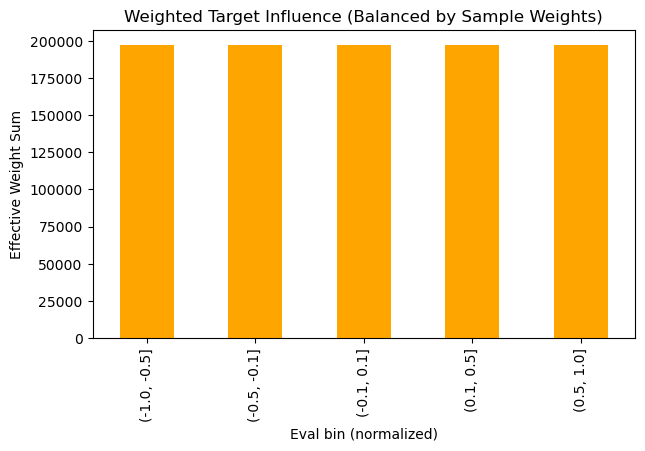

In [242]:
# Create bins for balancing
if 'bin' not in df.columns:
    df['bin'] = pd.cut(df['target'], bins=[-1, -0.5, -0.1, 0.1, 0.5, 1])

# Compute inverse frequency
bin_counts = df['bin'].value_counts()
inv_freq = 1.0 / bin_counts

# Map inverse frequency to numeric weights
df['sample_weight'] = df['bin'].map(inv_freq).astype(float)

# Normalize to mean 1
df['sample_weight'] /= df['sample_weight'].mean()

# Compute weighted counts (how much each bin contributes after weighting)
weighted_counts = (
    df.groupby('bin', observed=False)['sample_weight']
    .sum()
    .sort_index()
)

# Print distributions
print("Raw bin distribution:")
print(bin_counts.sort_index())

print("\nRaw share per bin (%):")
print((bin_counts.sort_index() / len(df) * 100).round(2))

print("\nWeighted effective sample sum:")
print(weighted_counts.round(2))

print("\nSample weight dtype:", df['sample_weight'].dtype)

# Visualize weighted influence 
plt.figure(figsize=(7, 4))
weighted_counts.plot(kind='bar', color='orange')
plt.title('Weighted Target Influence (Balanced by Sample Weights)')
plt.xlabel('Eval bin (normalized)')
plt.ylabel('Effective Weight Sum')
plt.show()

## Train/test split

In [251]:
# Drop rows where bin is NaN 
df = df.dropna(subset=['bin']).reset_index(drop=True)

# Convert FEN to input arrays
X_list, y_list = [], []
for fen, cp in zip(df[fen_col].values, df['cp'].values):
    b = chess.Board(fen)
    cp_white = cp if b.turn == chess.WHITE else -cp
    X_list.append(fen_to_array(fen))
    y_list.append(cp_to_target(cp_white))

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

print("X shape:", X.shape)  # should be (N, 8, 8, 14)
print("y shape:", y.shape)

# Split dataset
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, df['sample_weight'],
    test_size=0.2,
    random_state=42,
    stratify=df['bin']
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

X shape: (987222, 8, 8, 14)
y shape: (987222,)
Train: (789777, 8, 8, 14), Test: (197445, 8, 8, 14)


## Neural network design

In [256]:
# Optimizer with weight decay
optimizer = AdamW(learning_rate=3e-4, weight_decay=1e-6)

# Define model
model = Sequential([
    Input(shape=(8, 8, 14)),

    # --- Conv Block 1 ---
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(negative_slope=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # --- Conv Block 2 ---
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(negative_slope=0.1),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # --- Conv Block 3 (new) ---
    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(negative_slope=0.1),
    Dropout(0.2),

    # --- Dense layers ---
    Flatten(),
    Dense(256),
    LeakyReLU(negative_slope=0.1),
    Dropout(0.2),

    Dense(128),
    LeakyReLU(negative_slope=0.1),

    Dense(1, activation='tanh')
])

def rmse_cp(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred))) * 3000

# Compile model
model.compile(optimizer=optimizer, loss='mse', metrics=['mse', rmse_cp])

# Callbacks to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.7, patience=6, min_lr=1e-6, verbose=1)

# Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
3086/3086 ━━━━━━━━━━━━━━━━━━━━ 95s 30ms/step - loss: 0.2021 - mse: 0.0831 - rmse_cp: 1019.7659 - val_loss: 0.1262 - val_mse: 0.0481 - val_rmse_cp: 907.5789 - learning_rate: 3.0000e-04
Epoch 2/200
3086/3086 ━━━━━━━━━━━━━━━━━━━━ 97s 31ms/step - loss: 0.1233 - mse: 0.0481 - rmse_cp: 923.7252 - val_loss: 0.1077 - val_mse: 0.0374 - val_rmse_cp: 865.2269 - learning_rate: 3.0000e-04
Epoch 3/200
3086/3086 ━━━━━━━━━━━━━━━━━━━━ 92s 30ms/step - loss: 0.1115 - mse: 0.0474 - rmse_cp: 934.2861 - val_loss: 0.1050 - val_mse: 0.0417 - val_rmse_cp: 905.3159 - learning_rate: 3.0000e-04
Epoch 4/200
3086/3086 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - loss: 0.1050 - mse: 0.0453 - rmse_cp: 928.7256 - val_loss: 0.1062 - val_mse: 0.0354 - val_rmse_cp: 846.9603 - learning_rate: 3.0000e-04
Epoch 5/200
3086/3086 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - loss: 0.0977 - mse: 0.0439 - rmse_cp: 922.4939 - val_loss: 0.1033 - val_mse: 0.0398 - val_rmse_cp: 885.6063 - learning_rate: 3.0000e-04
Epoch 6/200
3086/3086 ━━

Test MSE (normalized): 0.030114
Test RMSE (centipawns): 520.60


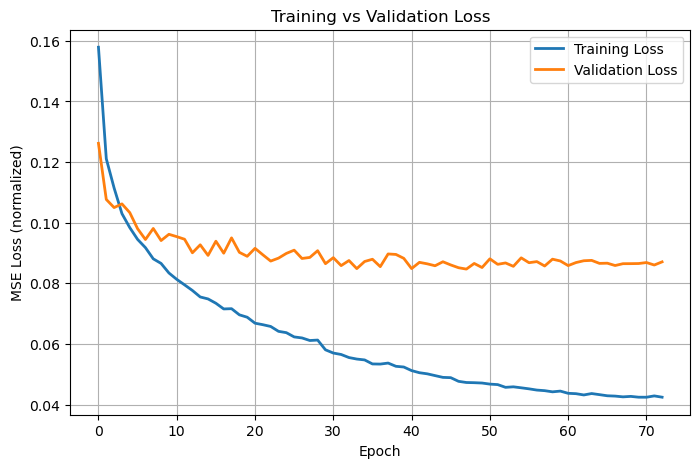

In [266]:
# Evaluate model performance
test_loss, test_mse, test_rmse_cp = model.evaluate(X_test, y_test, verbose=0)

# Convert metrics to centipawns for easier interpretation
test_rmse_cp = np.sqrt(test_loss) * CP_CLIP

print(f"Test MSE (normalized): {test_loss:.6f}")
print(f"Test RMSE (centipawns): {test_rmse_cp:.2f}")

# Plot training and validation loss curves
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Visualize learning rate changes
if 'lr' in history.history:
    plt.figure(figsize=(8,4))
    plt.plot(history.history['lr'])
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.grid(True)
    plt.show()

In [268]:
# Save model for use by the chess app 
MODEL_PATH = "ml_chess_eval.keras" 
model.save(MODEL_PATH) 
print("Saved:", MODEL_PATH)

Saved: ml_chess_eval.keras


In [270]:
# -------------------------------
# MACHINE LEARNING-BASED EVALUATION
# -------------------------------

ML_MODEL_PATH = "ml_chess_eval.keras"
MATE_VALUE = 10_000

_ml_model = None  # cached model instance

def _get_model():
    """Load and cache the ML evaluation model."""
    global _ml_model
    if _ml_model is None:
        _ml_model = load_model(ML_MODEL_PATH)
    return _ml_model

@lru_cache(maxsize=10000)
def evaluate_board_ml_cached(fen: str) -> int:
    """Cached version of ML evaluation for repeated board states."""
    model = _get_model()
    fen_vec = fen_to_array(fen).reshape(1, -1)
    normalized_score = float(model.predict(fen_vec, verbose=0)[0][0])

    # Clip prediction to valid range
    normalized_score = np.clip(normalized_score, -1.0, 1.0)
    cp_score = target_to_cp(normalized_score)
    return int(round(cp_score))
    
def evaluate_board_ml(board: chess.Board) -> int:
    """Return evaluation of the given chess board in centipawns."""
    if board.is_game_over():
        outcome = board.outcome()
        if outcome is None or outcome.winner is None:
            return 0
        return MATE_VALUE if outcome.winner == chess.WHITE else -MATE_VALUE
    try:
        return evaluate_board_ml_cached(board.fen())
    except Exception as e:
        print("Evaluation error:", e)
        return 0  # fallback neutral evaluation

In [272]:
# -------------------------------
#           ENGINE
# -------------------------------

PIECE_VALUES = {
    chess.PAWN:   100,
    chess.KNIGHT: 320,
    chess.BISHOP: 330,
    chess.ROOK:   500,
    chess.QUEEN:  900,
    chess.KING:   0,  # handled via mate scores
}

PAWN_TABLE = [
      0,  0,  0,  0,  0,  0,  0,  0,
     50, 50, 50, 50, 50, 50, 50, 50,
     10, 10, 20, 30, 30, 20, 10, 10,
      5,  5, 10, 25, 25, 10,  5,  5,
      0,  0,  0, 20, 20,  0,  0,  0,
      5, -5,-10,  0,  0,-10, -5,  5,
      5, 10, 10,-20,-20, 10, 10,  5,
      0,  0,  0,  0,  0,  0,  0,  0,
]
KNIGHT_TABLE = [
    -50,-40,-30,-30,-30,-30,-40,-50,
    -40,-20,  0,  5,  5,  0,-20,-40,
    -30,  5, 10, 15, 15, 10,  5,-30,
    -30,  0, 15, 20, 20, 15,  0,-30,
    -30,  5, 15, 20, 20, 15,  5,-30,
    -30,  0, 10, 15, 15, 10,  0,-30,
    -40,-20,  0,  0,  0,  0,-20,-40,
    -50,-40,-30,-30,-30,-30,-40,-50,
]
BISHOP_TABLE = [
    -20,-10,-10,-10,-10,-10,-10,-20,
    -10,  5,  0,  0,  0,  0,  5,-10,
    -10, 10, 10, 10, 10, 10, 10,-10,
    -10,  0, 10, 10, 10, 10,  0,-10,
    -10,  5,  5, 10, 10,  5,  5,-10,
    -10,  0,  5, 10, 10,  5,  0,-10,
    -10,  0,  0,  0,  0,  0,  0,-10,
    -20,-10,-10,-10,-10,-10,-10,-20,
]
ROOK_TABLE = [
     0,  0,  0,  5,  5,  0,  0,  0,
    -5,  0,  0,  0,  0,  0,  0, -5,
    -5,  0,  0,  0,  0,  0,  0, -5,
    -5,  0,  0,  0,  0,  0,  0, -5,
    -5,  0,  0,  0,  0,  0,  0, -5,
    -5,  0,  0,  0,  0,  0,  0, -5,
     5, 10, 10, 10, 10, 10, 10,  5,
     0,  0,  0,  0,  0,  0,  0,  0,
]
QUEEN_TABLE = [
    -20,-10,-10, -5, -5,-10,-10,-20,
    -10,  0,  5,  0,  0,  0,  0,-10,
    -10,  5,  5,  5,  5,  5,  0,-10,
     -5,  0,  5,  5,  5,  5,  0, -5,
      0,  0,  5,  5,  5,  5,  0, -5,
    -10,  0,  5,  5,  5,  5,  0,-10,
    -10,  0,  0,  0,  0,  0,  0,-10,
    -20,-10,-10, -5, -5,-10,-10,-20,
]
KING_TABLE = [
    -30,-40,-40,-50,-50,-40,-40,-30,
    -30,-40,-40,-50,-50,-40,-40,-30,
    -30,-40,-40,-50,-50,-40,-40,-30,
    -30,-40,-40,-50,-50,-40,-40,-30,
    -20,-30,-30,-40,-40,-30,-30,-20,
    -10,-20,-20,-20,-20,-20,-20,-10,
     20, 20,  0,  0,  0,  0, 20, 20,
     20, 30, 10,  0,  0, 10, 30, 20,
]
PST = {
    chess.PAWN:   PAWN_TABLE,
    chess.KNIGHT: KNIGHT_TABLE,
    chess.BISHOP: BISHOP_TABLE,
    chess.ROOK:   ROOK_TABLE,
    chess.QUEEN:  QUEEN_TABLE,
    chess.KING:   KING_TABLE
}

USE_ML_EVALUATION = True

def evaluate_board_raw(board: chess.Board) -> int:
    """Main evaluation function - uses ML by default."""
    if USE_ML_EVALUATION:
        return evaluate_board_ml(board)
    else:   
        # original evaluation logic 
        if board.is_game_over():
            outcome = board.outcome()
            if outcome is None or outcome.winner is None:
                return 0
            return MATE_VALUE if outcome.winner == chess.WHITE else -MATE_VALUE

    score = 0
    for sq, piece in board.piece_map().items():
        base = PIECE_VALUES[piece.piece_type]
        if piece.color == chess.WHITE:
            score += base + PST[piece.piece_type][sq]
        else:
            score -= base + PST[piece.piece_type][chess.square_mirror(sq)]
    return score

def eval_for_color(board: chess.Board, ai_color: chess.Color) -> int:
    raw = evaluate_board_raw(board)
    return raw if ai_color == chess.WHITE else -raw

def move_order_key(board: chess.Board, move: chess.Move) -> int:
    score = 0
    if board.is_capture(move):
        captured = board.piece_type_at(move.to_square)
        attacker = board.piece_type_at(move.from_square)
        if captured:
            score += 10 * PIECE_VALUES[captured] - PIECE_VALUES.get(attacker, 0)
        else:
            score += 500
    if move.promotion:
        score += PIECE_VALUES.get(move.promotion, 0)
    board.push(move)
    if board.is_check():
        score += 50
    board.pop()
    return score

def ordered_moves(board: chess.Board) -> List[chess.Move]:
    ms = list(board.legal_moves)
    ms.sort(key=lambda m: move_order_key(board, m), reverse=True)
    return ms

def minimax(board: chess.Board, depth: int, alpha: int, beta: int, ai_color: chess.Color) -> Tuple[int, Optional[chess.Move]]:
    if depth == 0 or board.is_game_over():
        return eval_for_color(board, ai_color), None

    maximizing = (board.turn == ai_color)
    best_move = None

    if maximizing:
        best = -math.inf
        for mv in ordered_moves(board):
            board.push(mv)
            val, _ = minimax(board, depth - 1, alpha, beta, ai_color)
            board.pop()
            if val > best:
                best, best_move = val, mv
            alpha = max(alpha, best)
            if beta <= alpha:
                break
        return int(best), best_move
    else:
        best = math.inf
        for mv in ordered_moves(board):
            board.push(mv)
            val, _ = minimax(board, depth - 1, alpha, beta, ai_color)
            board.pop()
            if val < best:
                best, best_move = val, mv
            beta = min(beta, best)
            if beta <= alpha:
                break
        return int(best), best_move

def best_move(board: chess.Board, depth: int, ai_color: chess.Color) -> Optional[chess.Move]:
    score, mv = minimax(board, depth, -math.inf, math.inf, ai_color)
    return mv

# -------------------------------
#           UI (ipywidgets)
# -------------------------------

# Piece glyphs
GLYPH = {
    'P':'♙','N':'♘','B':'♗','R':'♖','Q':'♕','K':'♔',
    'p':'♟','n':'♞','b':'♝','r':'♜','q':'♛','k':'♚',
}
LIGHT = '#F0D9B5'
DARK  = '#B58863'
SEL   = '#f6f67a'
TARGET= '#b9e6a1'
CAPT  = '#f5a3a3'

# Optional: bump button font-size
display(HTML("<style>.widget-button{font-size:22px !important;}</style>"))

@dataclass
class GameState:
    board: chess.Board
    ai_color: Optional[chess.Color]  # None for 2-player mode
    depth: int
    orientation_white: bool  # True = white-bottom view

    def status_text(self) -> str:
        if self.board.is_game_over():
            outcome = self.board.outcome()
            if outcome is None or outcome.winner is None:
                return "Game over · Draw"
            return "Game over · " + ("White wins" if outcome.winner == chess.WHITE else "Black wins")
        who = "White" if self.board.turn == chess.WHITE else "Black"
        check = " · Check!" if self.board.is_check() else ""
        return f"Turn: {who}{check}"

class ChessApp:
    def __init__(self):
        # Controls
        self.mode = W.ToggleButtons(options=[('Vs AI','ai'),('Two Players','2p')], value='ai', description='Mode:')
        self.color_sel = W.ToggleButtons(options=[('White','white'),('Black','black')], value='white', description='You:')
        self.depth = W.IntSlider(value=3, min=2, max=5, step=1, description='AI depth:')
        self.start_btn = W.Button(description='Start / Reset', button_style='primary')
        self.undo_btn = W.Button(description='Undo')
        self.flip_btn = W.Button(description='Flip')
        self.status = W.HTML("<b>Click Start / Reset to begin.</b>")
        self.log = W.HTML("")
        self.log_box = W.VBox([W.HTML("<b>Moves</b>"), W.Box([self.log], layout=W.Layout(max_height='220px', overflow='auto'))])

        # Promotion chooser (hidden until needed)
        self.promo_box = W.HBox([])
        self._promo_pending = None  # (from_sq, to_sq)

        # Board grid
        self.grid_box = W.GridBox(children=[], layout=W.Layout(grid_template_columns='repeat(8, 46px)', grid_gap='0px'))
        self.sq_buttons: Dict[int, W.Button] = {}  # square -> button
        self.selected_sq: Optional[int] = None
        self.legal_from_selected: List[chess.Move] = []

        # State
        self.state: Optional[GameState] = None

        # Wire controls
        self.start_btn.on_click(self.on_start)
        self.undo_btn.on_click(self.on_undo)
        self.flip_btn.on_click(self.on_flip)
        self.mode.observe(self.on_mode_change, 'value')

        # Build panel
        top = W.HBox([self.mode, self.color_sel, self.depth, self.start_btn, self.undo_btn, self.flip_btn])
        self.ui = W.VBox([top, self.status, self.promo_box, W.HBox([self.grid_box, self.log_box])])

        self._build_empty_grid()
        display(self.ui)

    # ---------- helpers ----------
    def _square_to_rc(self, sq: int) -> Tuple[int,int]:
        """Return (row, col) on the 8x8 grid for a given 0..63 square, given orientation."""
        file = chess.square_file(sq)
        rank = chess.square_rank(sq)
        if self.state and self.state.orientation_white:
            row = 7 - rank
            col = file
        else:
            row = rank
            col = 7 - file
        return row, col

    def _rc_to_square(self, row: int, col: int) -> int:
        """Return 0..63 square for grid (row, col)."""
        if self.state and self.state.orientation_white:
            rank = 7 - row
            file = col
        else:
            rank = row
            file = 7 - col
        return chess.square(file, rank)

    def _build_empty_grid(self):
        self.grid_box.children = ()
        self.sq_buttons.clear()
        children = []
        for row in range(8):
            for col in range(8):
                sq = self._rc_to_square(row, col)
                light = (row + col) % 2 == 0
                b = W.Button(description=' ', layout=W.Layout(width='46px', height='46px', padding='0'),
                             tooltip=chess.square_name(sq))
                b.style.button_color = LIGHT if light else DARK
                b.on_click(self._make_square_click(sq))
                self.sq_buttons[sq] = b
                children.append(b)
        self.grid_box.children = tuple(children)

    def _render_board(self):
        board = self.state.board
        # Clear any highlights if selection disappeared
        if self.selected_sq is not None and (self.selected_sq not in [m.from_square for m in board.legal_moves]):
            self.selected_sq = None
            self.legal_from_selected = []
        # Set base colors & glyphs
        for sq, btn in self.sq_buttons.items():
            row, col = self._square_to_rc(sq)
            light = (row + col) % 2 == 0
            btn.style.button_color = LIGHT if light else DARK
            piece = board.piece_at(sq)
            btn.description = GLYPH.get(piece.symbol(), ' ') if piece else ' '
        # Highlight selection and legal targets
        if self.selected_sq is not None:
            self.sq_buttons[self.selected_sq].style.button_color = SEL
            targets = [m.to_square for m in self.legal_from_selected]
            for m in self.legal_from_selected:
                tgt = m.to_square
                btn = self.sq_buttons[tgt]
                btn.style.button_color = CAPT if self.state.board.is_capture(m) else TARGET

        # Update status
        self.status.value = f"<b>{self.state.status_text()}</b>"

    def _append_log(self, text: str):
        self.log.value += f"{text}<br>"
        # cap log length a bit
        if self.log.value.count("<br>") > 200:
            self.log.value = "<i>(trimmed)</i><br>" + "<br>".join(self.log.value.split("<br>")[-200:])

    def _make_square_click(self, sq: int):
        def handler(_):
            if self.state is None or self.state.board.is_game_over():
                return
            # If promotion dialog visible, ignore board clicks
            if self._promo_pending is not None:
                return

            board = self.state.board

            # Whose turn is allowed to move?
            if self.state.ai_color is not None:
                human_turn = (board.turn != self.state.ai_color)
                if not human_turn:
                    return  # wait for AI
            # In 2-player mode both can move

            piece = board.piece_at(sq)
            if self.selected_sq is None:
                # First click: must be a piece of side to move
                if piece is None or piece.color != board.turn:
                    return
                self.selected_sq = sq
                self.legal_from_selected = [m for m in board.legal_moves if m.from_square == sq]
                self._render_board()
                return
            else:
                # Second click: attempt move
                if sq == self.selected_sq:
                    self.selected_sq = None
                    self.legal_from_selected = []
                    self._render_board()
                    return

                # Allow reselecting another own piece
                if piece is not None and piece.color == board.turn:
                    self.selected_sq = sq
                    self.legal_from_selected = [m for m in board.legal_moves if m.from_square == sq]
                    self._render_board()
                    return

                # Try to move selected -> sq (with possible promotion)
                legal_targets = [m for m in self.legal_from_selected if m.to_square == sq]
                if not legal_targets:
                    return

                # Promotion handling: if any candidate has a promotion, ask
                promos = [m for m in legal_targets if m.promotion]
                if promos:
                    self._prompt_promotion(self.selected_sq, sq, promos)
                    return

                # Otherwise, there should be exactly one legal move
                mv = legal_targets[0]
                self._play_human_move(mv)
        return handler

    def _prompt_promotion(self, from_sq: int, to_sq: int, promo_moves: List[chess.Move]):
        # Show small chooser
        self._promo_pending = (from_sq, to_sq)
        opts = [('Queen','q'),('Rook','r'),('Bishop','b'),('Knight','n')]
        picker = W.ToggleButtons(options=opts, value='q', description='Promote:')
        ok_btn = W.Button(description='OK', button_style='success')
        cancel_btn = W.Button(description='Cancel')
        msg = W.HTML("")

        def on_ok(_):
            letter = picker.value
            promo_map = {'q':chess.QUEEN,'r':chess.ROOK,'b':chess.BISHOP,'n':chess.KNIGHT}
            promo_piece = promo_map[letter]
            # find matching legal move
            for m in promo_moves:
                if m.from_square == from_sq and m.to_square == to_sq and m.promotion == promo_piece:
                    self._clear_promo_ui()
                    self._play_human_move(m)
                    return
            msg.value = "<span style='color:#b91c1c'>Not a legal promotion.</span>"

        def on_cancel(_):
            self._clear_promo_ui()
            # keep selection so user can try again

        ok_btn.on_click(on_ok)
        cancel_btn.on_click(on_cancel)
        self.promo_box.children = [picker, ok_btn, cancel_btn, msg]

    def _clear_promo_ui(self):
        self.promo_box.children = []
        self._promo_pending = None

    # ---------- actions ----------
    def on_start(self, _):
        human_color = self.color_sel.value
        ai = (None if self.mode.value == '2p'
              else (chess.BLACK if human_color == 'white' else chess.WHITE))
        self.state = GameState(board=chess.Board(), ai_color=ai, depth=int(self.depth.value),
                               orientation_white=True if human_color=='white' else False)
        self.selected_sq = None
        self.legal_from_selected = []
        self._build_empty_grid()
        self.log.value = ""
        self._clear_promo_ui()

        # If AI plays first (AI = white)
        if self.state.ai_color == chess.WHITE and self.state.board.turn == chess.WHITE:
            mv = best_move(self.state.board, self.state.depth, self.state.ai_color)
            if mv:
                san = self.state.board.san(mv)
                self.state.board.push(mv)
                self._append_log(f"AI: {san}")
        self._render_board()

    def on_undo(self, _):
        if not self.state: return
        b = self.state.board
        undone = 0
        if len(b.move_stack): b.pop(); undone += 1
        if self.state.ai_color is not None and len(b.move_stack):
            # try undo a full pair vs AI
            b.pop(); undone += 1
        self.selected_sq = None
        self.legal_from_selected = []
        self._append_log(f"<i>Undid {undone} half-move(s).</i>")
        self._render_board()

    def on_flip(self, _):
        if not self.state: return
        self.state.orientation_white = not self.state.orientation_white
        self._build_empty_grid()
        self._render_board()

    def on_mode_change(self, change):
        # Enable/disable controls based on mode
        is_ai = change['new'] == 'ai'
        self.color_sel.disabled = not is_ai
        self.depth.disabled = not is_ai

    def _play_human_move(self, mv: chess.Move):
        b = self.state.board
        san = b.san(mv)
        b.push(mv)
        self._append_log(f"You: {san}")
        self.selected_sq = None
        self.legal_from_selected = []
        self._render_board()
        # If game not over and vs AI, let AI respond
        if not b.is_game_over() and self.state.ai_color is not None and b.turn == self.state.ai_color:
            thinking_msg = "<i>AI thinking...</i>"
            self._append_log(thinking_msg)
            self._render_board()
            reply = best_move(b, self.state.depth, self.state.ai_color)
            if reply:
                san2 = b.san(reply)
                b.push(reply)
                self.log.value = self.log.value.replace(thinking_msg + "<br>", "")
                self._append_log(f"AI: {san2}")
                self._render_board()

# Launch the app
ChessApp()